# European Power Market Analysis

Multi-country day-ahead price analysis using the **ENTSO-E Transparency Platform API**.

**Countries analysed:** Germany, France, Netherlands, Norway, Poland  
**Period:** March 2026 (31 days, hourly resolution)  
**Data source:** [ENTSO-E Transparency Platform](https://transparency.entsoe.eu)

## What this notebook covers:
| # | Analysis | Key question |
|---|----------|--------------|
| 1 | Multi-country price comparison | Which country is cheapest/most expensive? |
| 2 | Correlation matrix | How closely do prices move together? |
| 3 | Cross-border spread analysis | Where are the arbitrage opportunities? |
| 4 | Arbitrage P&L simulation | What would FR→DE arbitrage have earned? |
| 5 | Realistic vs theoretical P&L | How much do friction costs reduce returns? |

In [1]:
# Install ENTSO-E Python client
!pip install entsoe-py -q
print('entsoe-py installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.6 MB/s eta 0:00:00
entsoe-py installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
from entsoe import EntsoePandasClient
from google.colab import userdata

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load API token from Colab Secrets
# To set up: left sidebar → key icon → Add secret → Name: ENTSOE_TOKEN
api_key = userdata.get('ENTSOE_TOKEN')
client  = EntsoePandasClient(api_key=api_key)
print('ENTSO-E client ready.')

ENTSO-E client ready.


---
## 1 — Data Collection

Fetch day-ahead prices for 5 European countries.  
ENTSO-E returns **15-minute** resolution data — we resample to hourly.

**Country codes used:**
| Code | Country | Generation mix |
|------|---------|----------------|
| DE_LU | Germany | Wind, solar, gas, lignite |
| FR | France | Nuclear dominant (~70%) |
| NL | Netherlands | Gas, wind, interconnectors |
| NO_2 | Norway | Hydro dominant (~90%) |
| PL | Poland | Coal dominant (~70%) |

In [3]:
countries = {
    'DE_LU': 'Germany',
    'FR':    'France',
    'NL':    'Netherlands',
    'NO_2':  'Norway',
    'PL':    'Poland',
}

start = pd.Timestamp('20260301', tz='UTC')
end   = pd.Timestamp('20260401', tz='UTC')

dfs = {}
for code, name in countries.items():
    try:
        prices = client.query_day_ahead_prices(code, start=start, end=end)
        prices = prices.resample('h').mean()
        dfs[name] = prices
        print(f'{name:15} -> {len(prices)} hours fetched')
        time.sleep(1)
    except Exception as e:
        print(f'{name:15} -> Error: {e}')

df_eu = pd.DataFrame(dfs).dropna()
print(f'\nMerged dataset: {len(df_eu)} hours, {len(df_eu.columns)} countries')
print(df_eu.describe().round(1))

Germany         -> 745 hours fetched
France          -> 745 hours fetched
Netherlands     -> 745 hours fetched
Norway          -> 745 hours fetched
Poland          -> 745 hours fetched

Merged dataset: 745 hours, 5 countries
       Germany  France  Netherlands  Norway  Poland
count    745.0   745.0        745.0   745.0   745.0
mean      99.5    64.2         99.0   104.1   104.8
std       54.5    49.0         52.0    23.7    54.4
min      -11.8    -3.5        -15.7    25.6   -42.4
25%       66.1    19.7         68.3    92.6    81.8
50%      107.2    61.1        107.1   106.5   109.2
75%      135.2    97.5        130.4   119.0   137.4
max      310.9   218.1        309.6   194.6   289.8


---
## 2 — Price Comparison & Correlation

In [4]:
# Price statistics
stats = df_eu.agg(['mean','std','min','max']).round(1)
stats.loc['neg_hours'] = (df_eu < 0).sum()
stats.loc['neg_pct']   = ((df_eu < 0).mean() * 100).round(1)
print('── Price statistics by country ─────────────────────')
print(stats)

# Correlation matrix
print('\n── Correlation matrix ──────────────────────────────')
print(df_eu.corr().round(2))

── Price statistics by country ─────────────────────
           Germany  France  Netherlands  Norway  Poland
mean          99.5    64.2         99.0   104.1   104.8
std           54.5    49.0         52.0    23.7    54.4
min          -11.8    -3.5        -15.7    25.6   -42.4
max          310.9   218.1        309.6   194.6   289.8
neg_hours     35.0    39.0         20.0     0.0    39.0
neg_pct        4.7     5.2          2.7     0.0     5.2

── Correlation matrix ──────────────────────────────
             Germany  France  Netherlands  Norway  Poland
Germany         1.00    0.75         0.98    0.83    0.81
France          0.75    1.00         0.79    0.67    0.55
Netherlands     0.98    0.79         1.00    0.83    0.77
Norway          0.83    0.67         0.83    1.00    0.60
Poland          0.81    0.55         0.77    0.60    1.00


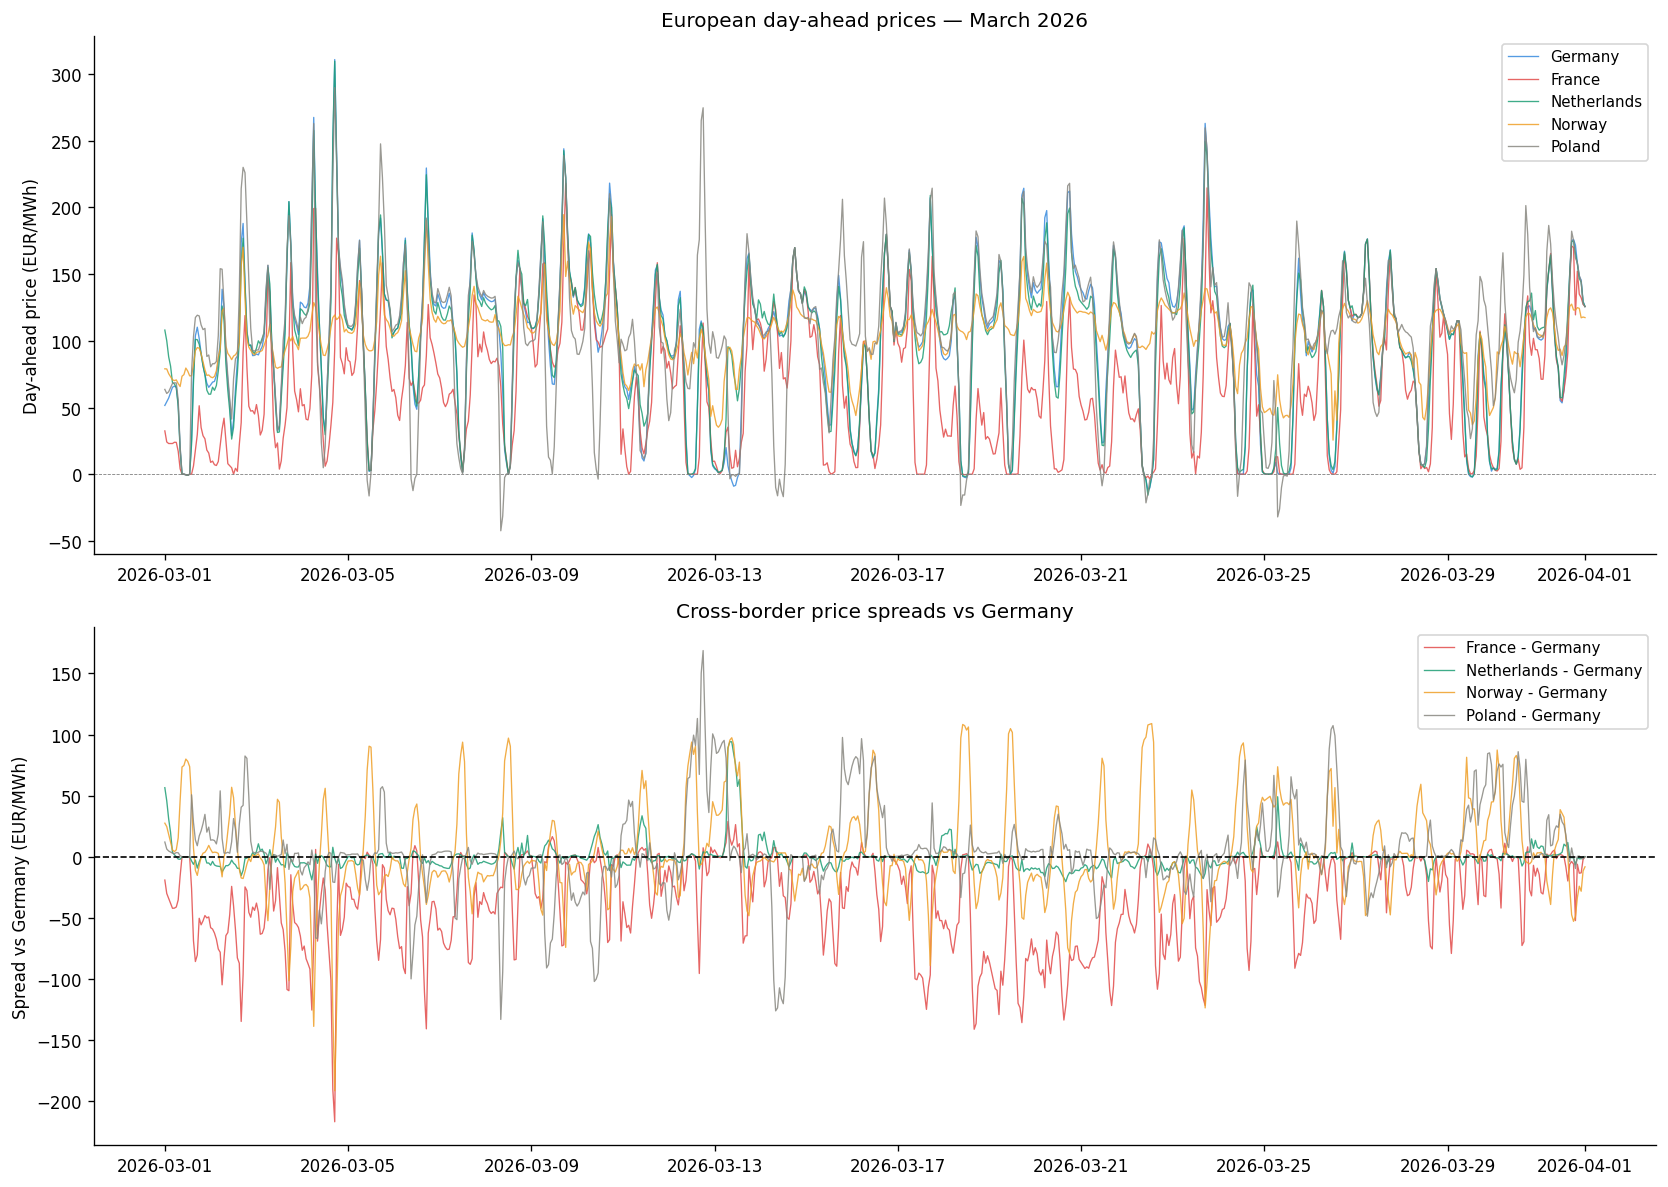

In [5]:
# Visualise prices and spreads
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors = ['#378ADD','#E24B4A','#1D9E75','#EF9F27','#888780']
for i, country in enumerate(df_eu.columns):
    axes[0].plot(df_eu.index, df_eu[country],
                 linewidth=0.8, alpha=0.85,
                 color=colors[i], label=country)
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Day-ahead price (EUR/MWh)')
axes[0].set_title('European day-ahead prices — March 2026')
axes[0].legend(loc='upper right', fontsize=9)

spread_colors = ['#E24B4A','#1D9E75','#EF9F27','#888780']
for i, country in enumerate(['France','Netherlands','Norway','Poland']):
    spread = df_eu[country] - df_eu['Germany']
    axes[1].plot(df_eu.index, spread,
                 linewidth=0.8, alpha=0.85,
                 color=spread_colors[i],
                 label=f'{country} - Germany')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_ylabel('Spread vs Germany (EUR/MWh)')
axes[1].set_title('Cross-border price spreads vs Germany')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

---
## 3 — Arbitrage Window Analysis

**Arbitrage** = buying in one market and selling in another to profit from price differences.

In power markets:
- Buy cheap electricity in country A
- Sell expensive electricity in country B
- Profit = price difference minus transmission cost

**Constraint:** Interconnector capacity is limited.  
When everyone wants to use the same line → **congestion** → prices cannot fully equalise.

In [6]:
# Arbitrage window statistics
transmission_cost = 5  # EUR/MWh

print('── Arbitrage window analysis vs Germany ────────────')
print(f'{"Country":15} {"Avg spread":>12} {"DE→Co %":>10} '
      f'{"Co→DE %":>10} {"Max spread":>12}')
print('-' * 65)

for country in ['France','Netherlands','Norway','Poland']:
    spread    = df_eu[country] - df_eu['Germany']
    de_to_co  = (spread >  transmission_cost).mean() * 100
    co_to_de  = (spread < -transmission_cost).mean() * 100
    avg       = spread.mean()
    max_s     = spread.abs().max()
    print(f'{country:15} {avg:>+11.1f}E {de_to_co:>9.1f}% '
          f'{co_to_de:>9.1f}% {max_s:>11.0f}E')

print()
print('DE→Co: hours when Germany is cheaper (buy DE, sell Co)')
print('Co→DE: hours when Co is cheaper (buy Co, sell DE)')

── Arbitrage window analysis vs Germany ────────────
Country           Avg spread    DE→Co %    Co→DE %   Max spread
-----------------------------------------------------------------
France                -35.3E       4.8%      68.5%         217E
Netherlands            -0.5E      10.3%      27.5%          94E
Norway                 +4.6E      35.0%      40.8%         192E
Poland                 +5.3E      32.8%      24.4%         169E

DE→Co: hours when Germany is cheaper (buy DE, sell Co)
Co→DE: hours when Co is cheaper (buy Co, sell DE)


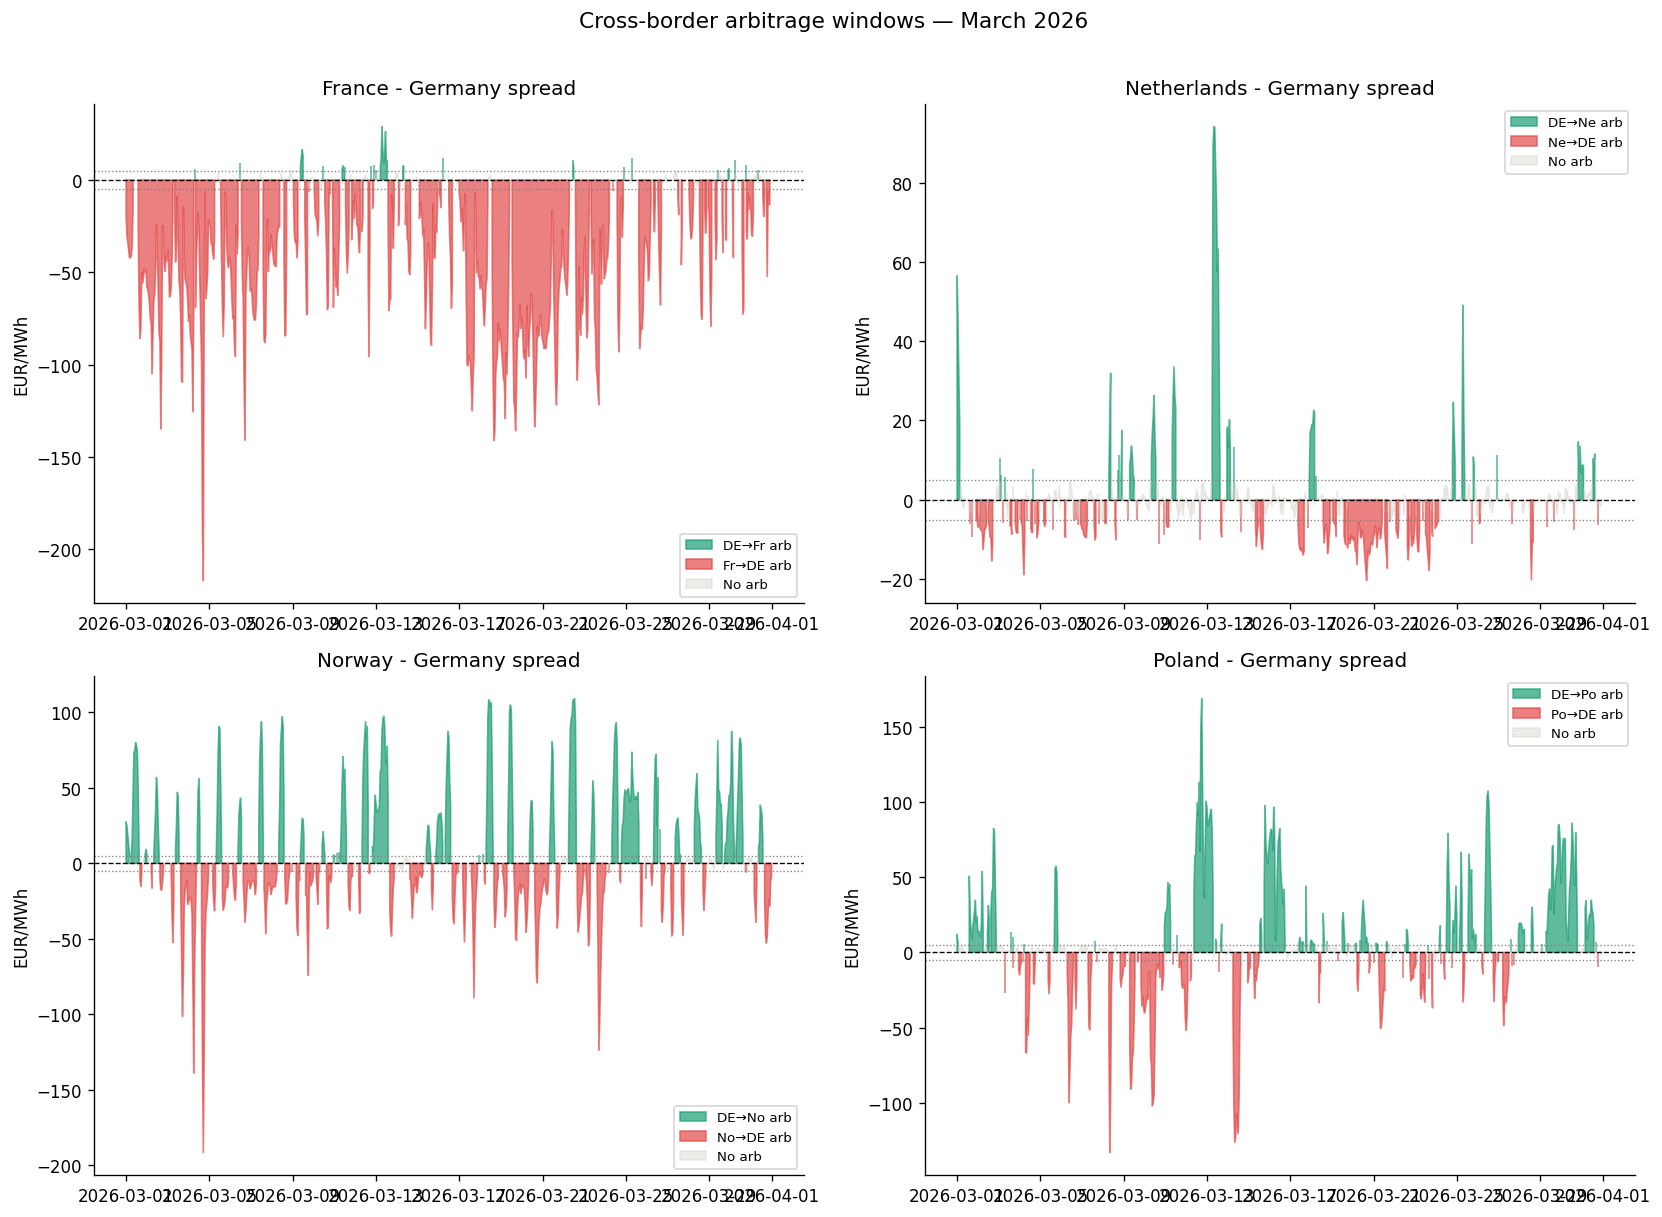

In [7]:
# Arbitrage window visualisation — 4 countries
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, country in enumerate(['France','Netherlands','Norway','Poland']):
    spread      = df_eu[country] - df_eu['Germany']
    arb_de_co   = spread >  transmission_cost
    arb_co_de   = spread < -transmission_cost
    no_arb      = ~arb_de_co & ~arb_co_de

    axes[idx].fill_between(df_eu.index, spread,
                           where=arb_de_co.values,
                           color='#1D9E75', alpha=0.7,
                           label=f'DE→{country[:2]} arb')
    axes[idx].fill_between(df_eu.index, spread,
                           where=arb_co_de.values,
                           color='#E24B4A', alpha=0.7,
                           label=f'{country[:2]}→DE arb')
    axes[idx].fill_between(df_eu.index, spread,
                           where=no_arb.values,
                           color='#D3D1C7', alpha=0.4,
                           label='No arb')
    axes[idx].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[idx].axhline( transmission_cost, color='gray',
                       linewidth=0.8, linestyle=':')
    axes[idx].axhline(-transmission_cost, color='gray',
                       linewidth=0.8, linestyle=':')
    axes[idx].set_title(f'{country} - Germany spread')
    axes[idx].set_ylabel('EUR/MWh')
    axes[idx].legend(fontsize=8)

plt.suptitle('Cross-border arbitrage windows — March 2026', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4 — FR→DE Arbitrage P&L Simulation

France was structurally cheaper than Germany throughout March 2026.  
This section simulates what a systematic FR→DE arbitrage strategy would have earned.

**Strategy:** Buy in France, sell in Germany whenever the spread covers transmission cost.

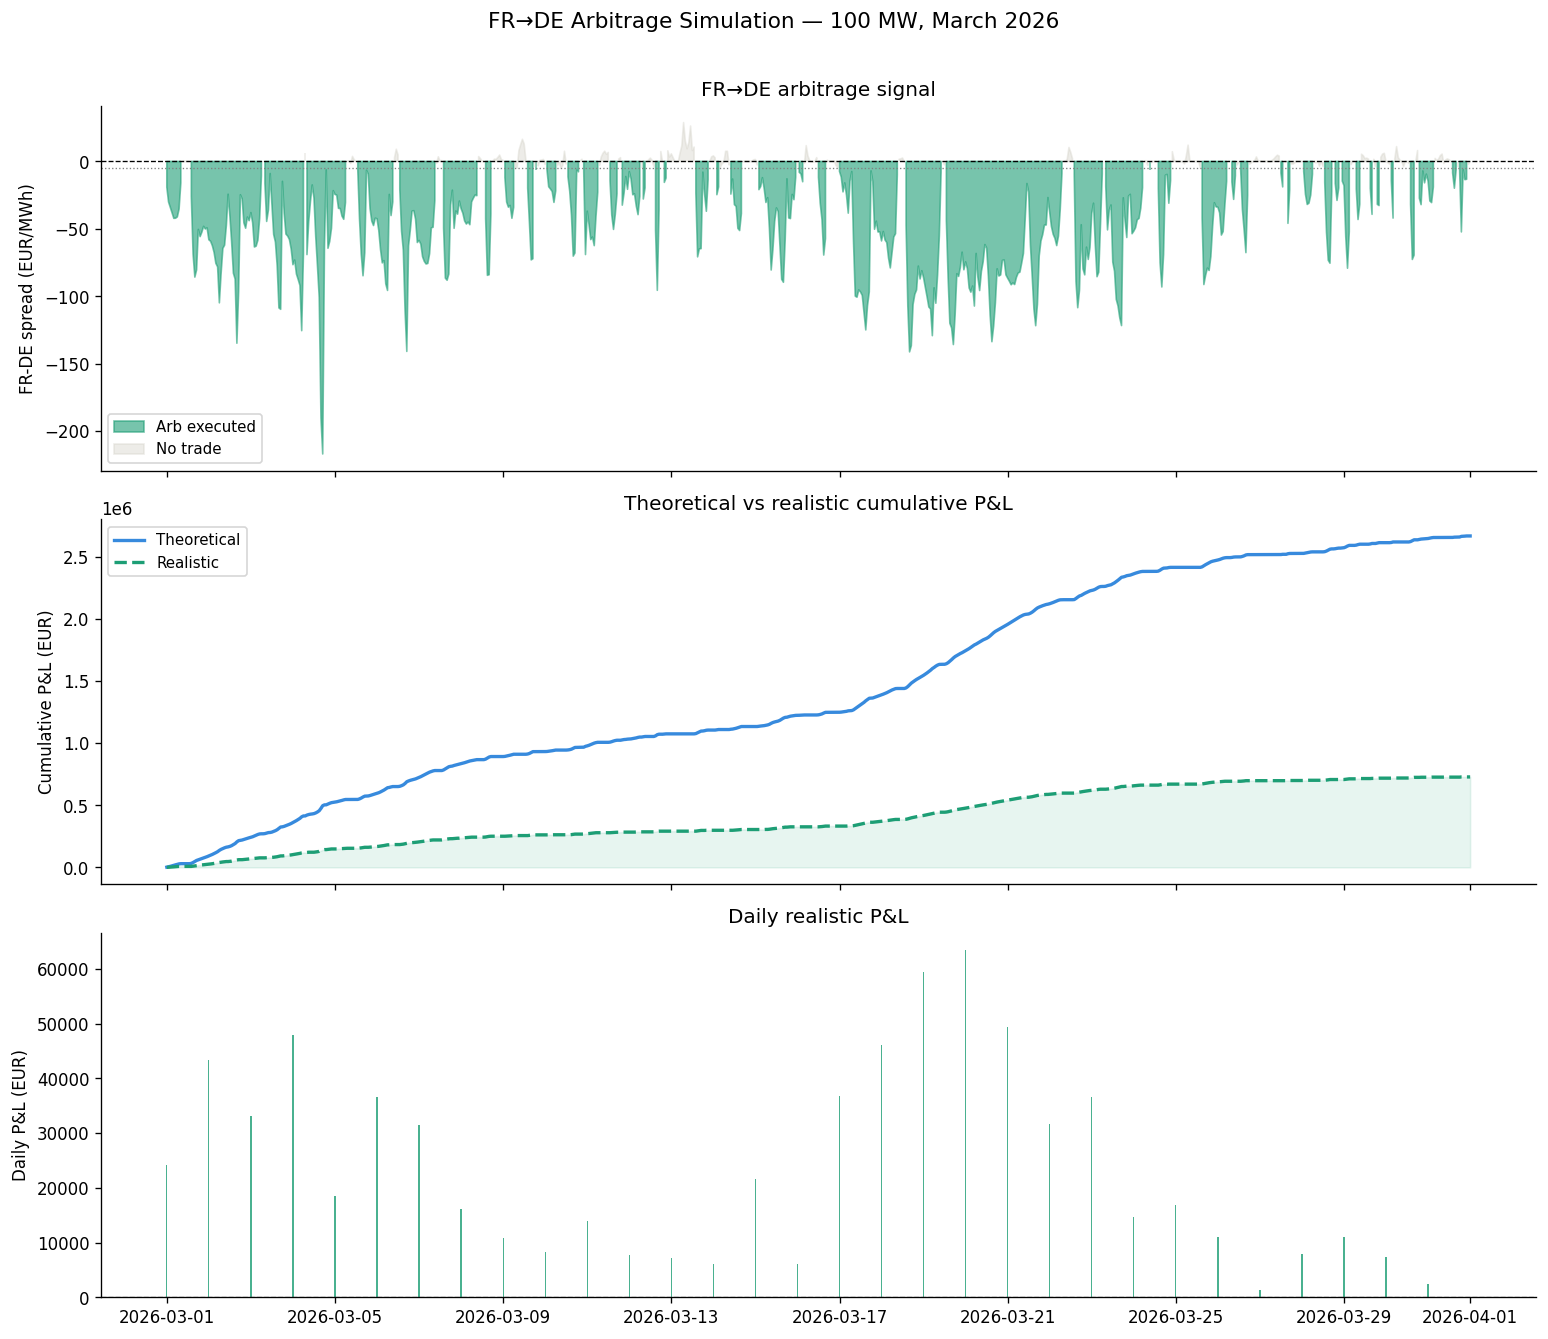

── Theoretical vs Realistic ────────────────────────
                           Theoretical       Realistic
Trades (hours)                     510             369
Total P&L (EUR)              2,670,735         728,810
Daily avg (EUR)                 86,153          23,510
Reduction                                        72.7%

Assumptions:
  Transmission cost : 5 EUR/MWh
  Auction cost      : 25 EUR/MWh
  Capacity available: 30%
  Position size     : 100 MW


In [8]:
# Theoretical P&L
spread_fr    = df_eu['France'] - df_eu['Germany']
capacity_mw  = 100

theo_signal  = spread_fr < -transmission_cost
theo_pnl     = theo_signal * abs(spread_fr) * capacity_mw
theo_cum     = theo_pnl.cumsum()

# Realistic P&L
capacity_utilization = 0.30
auction_cost         = 25

real_signal  = spread_fr < -(transmission_cost + auction_cost)
real_pnl     = real_signal * abs(spread_fr) * capacity_mw * capacity_utilization
real_cum     = real_pnl.cumsum()

# Visualise
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].fill_between(df_eu.index, spread_fr,
                     where=theo_signal.values,
                     color='#1D9E75', alpha=0.6, label='Arb executed')
axes[0].fill_between(df_eu.index, spread_fr,
                     where=~theo_signal.values,
                     color='#D3D1C7', alpha=0.4, label='No trade')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axhline(-transmission_cost, color='gray',
                linewidth=0.8, linestyle=':')
axes[0].set_ylabel('FR-DE spread (EUR/MWh)')
axes[0].set_title('FR→DE arbitrage signal')
axes[0].legend(fontsize=9)

axes[1].plot(theo_cum.index, theo_cum.values,
             color='#378ADD', linewidth=2, label='Theoretical')
axes[1].plot(real_cum.index, real_cum.values,
             color='#1D9E75', linewidth=2,
             linestyle='--', label='Realistic')
axes[1].fill_between(real_cum.index, real_cum.values,
                     alpha=0.1, color='#1D9E75')
axes[1].set_ylabel('Cumulative P&L (EUR)')
axes[1].set_title('Theoretical vs realistic cumulative P&L')
axes[1].legend(fontsize=9)

daily_real = real_pnl.resample('D').sum()
colors_d   = ['#1D9E75' if v > 0 else '#E24B4A' for v in daily_real]
axes[2].bar(daily_real.index, daily_real.values,
            color=colors_d, alpha=0.8, width=0.03)
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[2].set_ylabel('Daily P&L (EUR)')
axes[2].set_title('Daily realistic P&L')

plt.suptitle('FR→DE Arbitrage Simulation — 100 MW, March 2026',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('── Theoretical vs Realistic ────────────────────────')
print(f'{"":22} {"Theoretical":>15} {"Realistic":>15}')
print(f'{"Trades (hours)":22} {theo_signal.sum():>15} {real_signal.sum():>15}')
print(f'{"Total P&L (EUR)":22} {theo_cum.iloc[-1]:>15,.0f} '
      f'{real_cum.iloc[-1]:>15,.0f}')
print(f'{"Daily avg (EUR)":22} {theo_cum.iloc[-1]/31:>15,.0f} '
      f'{real_cum.iloc[-1]/31:>15,.0f}')
print(f'{"Reduction":22} {"":>15} '
      f'{(1-real_cum.iloc[-1]/theo_cum.iloc[-1])*100:>14.1f}%')
print()
print('Assumptions:')
print(f'  Transmission cost : {transmission_cost} EUR/MWh')
print(f'  Auction cost      : {auction_cost} EUR/MWh')
print(f'  Capacity available: {capacity_utilization*100:.0f}%')
print(f'  Position size     : {capacity_mw} MW')

---
## Key Findings

| Finding | Value | Implication |
|---------|-------|-------------|
| DE-NL correlation | 0.98 | Nearly same market — little arbitrage |
| FR avg spread vs DE | -35 EUR/MWh | France structurally cheaper (nuclear) |
| FR→DE arb frequency | 68.5% of hours | Persistent structural opportunity |
| Theoretical monthly P&L | 2.67M EUR/100MW | Upper bound — ignores friction |
| Realistic monthly P&L | ~730K EUR/100MW | After capacity & auction costs |
| Friction reduction | 72.7% | Real costs dominate small spreads |

## Why France is structurally cheaper than Germany
- France generates ~70% from nuclear — very low marginal cost (15 EUR/MWh)
- Germany relies more on gas during peak hours (95 EUR/MWh marginal cost)
- When German solar is low (evenings, cloudy days) the gap widens further

---
## Next steps
- **Turkish market analysis** — EPİAŞ API, GÖP/GİP spread
- **Congestion data** — fetch actual NTC from ENTSO-E
- **Forecasting** — predict cross-border spreads using weather + generation forecasts

> ENTSO-E API: [transparency.entsoe.eu](https://transparency.entsoe.eu)  
> EPİAŞ API: [seffaflik.epias.com.tr](https://seffaflik.epias.com.tr)